In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
import os

import operator

load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",   
    google_api_key=os.getenv('GEMINI_API_KEY')
)

In [3]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the review")

In [4]:
structured_model = model.with_structured_output(SentimentSchema)

In [5]:

prompt = "What is the sentiment of the following review - The software is bad"
structured_model.invoke(prompt)

SentimentSchema(sentiment='negative')

In [6]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [7]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment\n {state["review"]}'
    result = structured_model.invoke(prompt)

    sentiment = result.sentiment
    return {'sentiment': sentiment}

In [8]:
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnostics"]:
    if state["sentiment"] == "positive":
        return "positive_response"
    else:
        return "run_diagnostics"

In [9]:
def positive_response(state: ReviewState):
    prompt = f"""
    Write a warm thank you message in response to this review: \n\n{state['review']}\n\n
    Also, kindly ask the user to leave feedback on the website.
    Do not respond anything else
    """

    response = model.invoke(prompt).content
    structured_response = response[0]['text']
    return {'response': structured_response}

In [10]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description="The category of issue mentioned in review")
    tone: Literal["angry", "frustagted", "disappointed", "calm"] = Field(description="The emotional tone expressed by the user")
    urgency: Literal["low", "medium", "high"] = Field(description="How urgent or critical the issue appears to be")

diagnosis_model = model.with_structured_output(DiagnosisSchema)

In [11]:
def run_diagnostics(state: ReviewState):
    prompt = f"""
    Diagnose this negative review: \n\n{state['review']}\n
    Return issue_type, tone, urgency
"""
    
    response = diagnosis_model.invoke(prompt)
    return {"diagnosis": response.model_dump()}

In [12]:
def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""
    You are a support assistant.
    The user had a '{diagnosis["issue_type"]}' issue, sounded '{diagnosis["tone"]}', and marked urgency as '{diagnosis["urgency"]}'\n
    Write an empathetic, helpful resolution message 
"""
    
    output = model.invoke(prompt).content
    response = output[0]["text"]

    return {"response": response}

In [13]:
graph = StateGraph(ReviewState)

graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnostics", run_diagnostics)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)
graph.add_edge("run_diagnostics", "negative_response")
graph.add_edge("negative_response", END)

graph.add_edge("positive_response", END)

workflow = graph.compile()

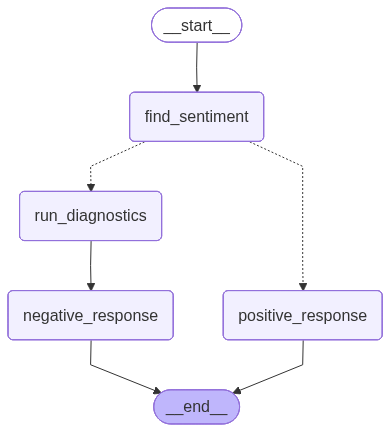

In [14]:
workflow

In [15]:
initial_state = {
    "review": "The product is really very very bad. It killed my kid. Remove it"
}

workflow.invoke(initial_state)

{'review': 'The product is really very very bad. It killed my kid. Remove it',
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Bug', 'tone': 'angry', 'urgency': 'high'},
 'response': 'Subject: Urgent: Resolution regarding your recent issue\n\nDear [User Name],\n\nI want to sincerely apologize for the frustration you’ve experienced with [mention specific bug/issue]. I completely understand how disruptive and aggravating it is to run into a problem like this, especially when you are counting on our service to work smoothly. Please know that your feedback is heard, and I am prioritizing this for you.\n\nI am pleased to inform you that our engineering team has [applied a fix / identified the root cause and implemented a resolution]. \n\n**To see the changes, please follow these steps:**\n1. [Step 1]\n2. [Step 2]\n3. [Step 3]\n\nCould you please verify if this has resolved the issue on your end? \n\nI know your time is valuable, and I am very sorry that we caused this interruption t

In [ ]:
initial_state = {
    "review": "The product is really very very bad. It killed my kid. Remove it"
}

workflow.invoke(initial_state)

{'review': 'Absolutely amazing product. My family is alive because of this product. Thank you so much',
 'sentiment': 'positive',
 'response': 'We are incredibly moved and honored to hear such a powerful sentiment. Knowing that our product has made such a profound difference for your family means the world to us—thank you for sharing that with us.\n\nIf you have a moment, would you be willing to share this feedback on our website? It would mean a lot to our team and helps others learn about the impact of our work. Thank you again for your kindness.'}